<a href="https://colab.research.google.com/github/MacarenaAPR/Rediseno-La-Mechada-Real/blob/main/ev02_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

Importamos el dataset caso3_municipio.csv y procedemos a ver la informacion qe contiene. verificamos si existen datos null y en base a la variable no_renuevan veremos el comportamiento de los datos null

In [ ]:
df = pd.read_csv("caso3_municipio.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   beneficiario_id         1800 non-null   object 
 1   tramo_etario            1800 non-null   object 
 2   genero                  1800 non-null   object 
 3   sector_comuna           1800 non-null   object 
 4   nivel_vulnerabilidad    1800 non-null   object 
 5   programa_principal      1800 non-null   object 
 6   num_beneficios_activos  1800 non-null   int64  
 7   recibe_mas_de_uno       1800 non-null   int64  
 8   monto_mensual_clp       1800 non-null   int64  
 9   dias_tramite            1800 non-null   int64  
 10  num_visitas_asistente   1642 non-null   float64
 11  postulo_digitalmente    1800 non-null   int64  
 12  documentos_completos    1800 non-null   int64  
 13  anios_en_sistema        1800 non-null   float64
 14  renovaciones_previas    1800 non-null   

In [ ]:
df.isnull().sum()

,0
beneficiario_id,0
tramo_etario,0
genero,0
sector_comuna,0
nivel_vulnerabilidad,0
programa_principal,0
num_beneficios_activos,0
recibe_mas_de_uno,0
monto_mensual_clp,0
dias_tramite,0


In [ ]:
df.groupby('no_renueva')['num_visitas_asistente'].count()

,num_visitas_asistente
no_renueva,
0,1028
1,614


In [ ]:
df['grupo_visitas'] = pd.cut(df['num_visitas_asistente'], bins=5)

pd.crosstab(df['grupo_visitas'], df['no_renueva'])

no_renueva,0,1
grupo_visitas,,
"(-0.009, 1.8]",266,208
"(1.8, 3.6]",503,298
"(3.6, 5.4]",198,96
"(5.4, 7.2]",51,12
"(7.2, 9.0]",10,0


pudimos aprecia qe si es una variable importante por tanto no se eliminara la columna con sus datos y se reajustara luego con knn, procederemos a eliminar columnas sin mayor influencia.

In [ ]:
df.drop(["beneficiario_id","fuente_datos","direccion_texto"], axis=1, inplace=True)
#con esto eliminamos variables irrelevantes para el modelo

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   tramo_etario            1800 non-null   object  
 1   genero                  1800 non-null   object  
 2   sector_comuna           1800 non-null   object  
 3   nivel_vulnerabilidad    1800 non-null   object  
 4   programa_principal      1800 non-null   object  
 5   num_beneficios_activos  1800 non-null   int64   
 6   recibe_mas_de_uno       1800 non-null   int64   
 7   monto_mensual_clp       1800 non-null   int64   
 8   dias_tramite            1800 non-null   int64   
 9   num_visitas_asistente   1642 non-null   float64 
 10  postulo_digitalmente    1800 non-null   int64   
 11  documentos_completos    1800 non-null   int64   
 12  anios_en_sistema        1800 non-null   float64 
 13  renovaciones_previas    1800 non-null   int64   
 14  tuvo_baja_anterior      

In [ ]:
df.isnull().sum()

,0
tramo_etario,0
genero,0
sector_comuna,0
nivel_vulnerabilidad,0
programa_principal,0
num_beneficios_activos,0
recibe_mas_de_uno,0
monto_mensual_clp,0
dias_tramite,0
num_visitas_asistente,158


In [ ]:
df.describe()

,num_beneficios_activos,recibe_mas_de_uno,monto_mensual_clp,dias_tramite,num_visitas_asistente,postulo_digitalmente,documentos_completos,anios_en_sistema,renovaciones_previas,tuvo_baja_anterior,no_renueva
count,1800.000000,1800.000000,1800.000000,1800.000000,1642.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,1.974444,0.518889,85467.777778,32.017222,2.464677,0.333333,0.775000,3.033056,2.527222,0.217778,0.380000
std,1.213420,0.499782,84312.760246,17.014470,1.591502,0.471536,0.417698,3.014652,1.573945,0.412850,0.485521
min,1.000000,0.000000,10000.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,24000.000000,20.000000,1.000000,0.000000,1.000000,0.800000,1.000000,0.000000,0.000000
50%,2.000000,1.000000,59000.000000,31.000000,2.000000,0.000000,1.000000,2.100000,2.000000,0.000000,0.000000
75%,3.000000,1.000000,117250.000000,44.000000,3.000000,1.000000,1.000000,4.300000,3.000000,0.000000,1.000000
max,7.000000,1.000000,450000.000000,99.000000,9.000000,1.000000,1.000000,15.000000,10.000000,1.000000,1.000000


In [ ]:
df["no_renueva"].value_counts()
# 0 = si renueva
# 1 = no renueva.

,count
no_renueva,
0,1116
1,684


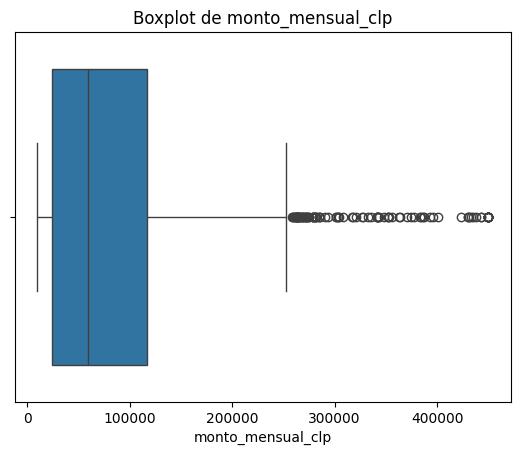

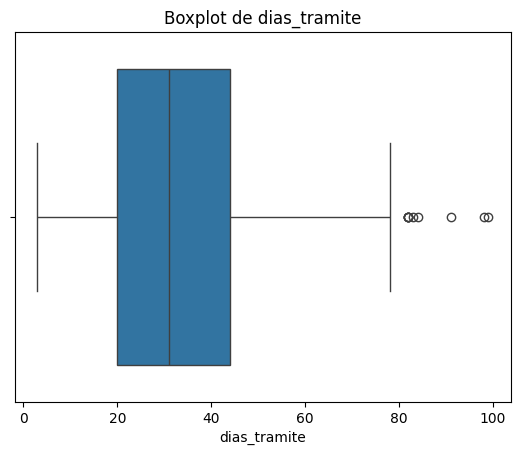

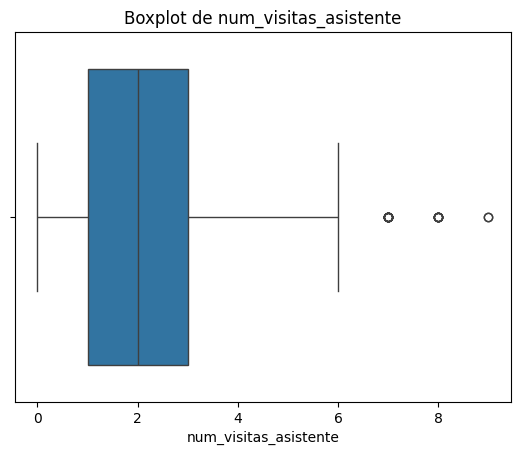

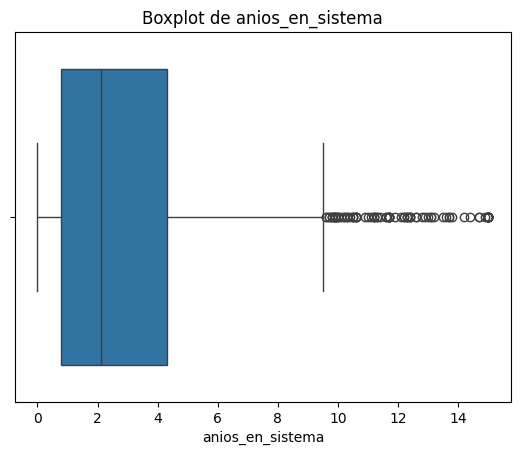

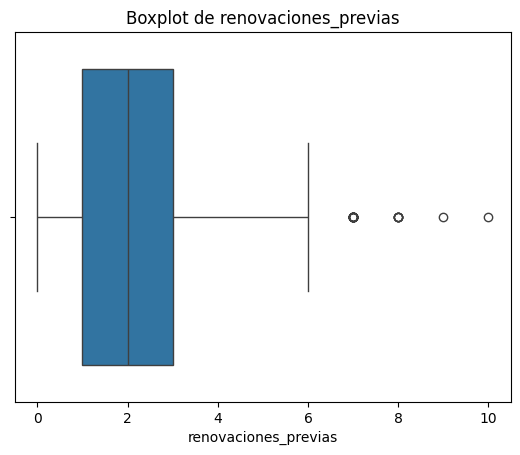

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

columnas_numericas = [
    'monto_mensual_clp',
    'dias_tramite',
    'num_visitas_asistente',
    'anios_en_sistema',
    'renovaciones_previas'
]

for col in columnas_numericas:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

Mediante el uso de boxplots se identificó la presencia de valores atípicos en variables como el monto mensual, evidenciando una distribución sesgada con algunos valores considerablemente más altos que la mayoría. Estos valores fueron mantenidos en el análisis, ya que pueden representar casos reales relevantes dentro del sistema

procedemos a hacer unos grafico en base a la variable no renueva y eliminacion de las variables anteriores considerar qe aun no se ajusta la varaible  con campo null

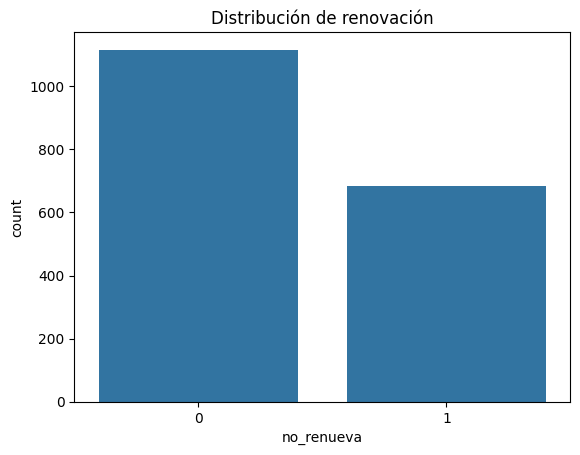

In [ ]:
sns.countplot(x='no_renueva', data=df)
plt.title("Distribución de renovación")
plt.show()

In [ ]:
pd.crosstab(df['nivel_vulnerabilidad'], df['no_renueva'])


no_renueva,0,1
nivel_vulnerabilidad,,
alta,359,200
baja,162,103
extrema,161,145
media,434,236


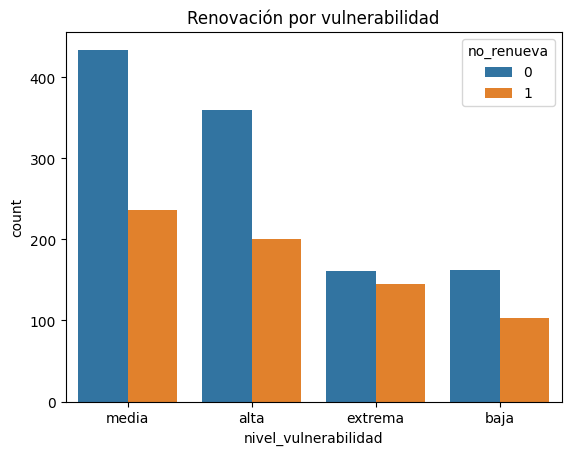

In [ ]:
sns.countplot(x='nivel_vulnerabilidad', hue='no_renueva', data=df)
plt.title("Renovación por vulnerabilidad")
plt.show()

#se observa qe el nivel de vulnerabilidad es una
#variable influyente en la toma de desision de
#renovacion.

In [ ]:
pd.crosstab(df['genero'], df['no_renueva'])

no_renueva,0,1
genero,,
F,645,395
M,441,277
NB,30,12


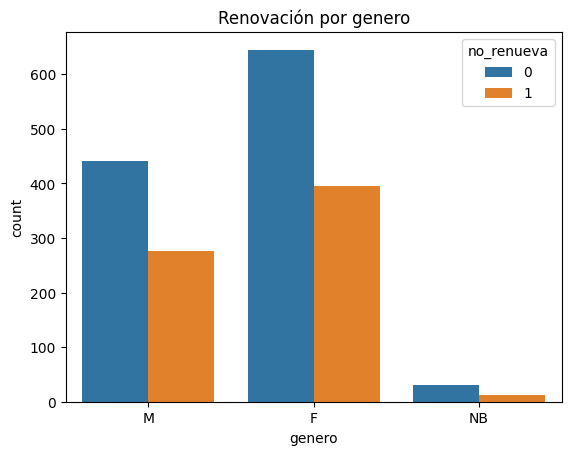

In [ ]:
sns.countplot(x='genero', hue='no_renueva', data=df)
plt.title("Renovación por genero")
plt.show()

In [ ]:
pd.crosstab(df['programa_principal'], df['no_renueva']).sort_values(by=1, ascending=False)
tabla = pd.crosstab(df['programa_principal'], df['no_renueva'])
tabla['total'] = tabla[0] + tabla[1]
tabla = tabla.sort_values(by=1, ascending=False)
tabla

no_renueva,0,1,total
programa_principal,,,
bono_invierno,213,130,343
adulto_mayor,147,103,250
beca_escolar,174,93,267
alimentacion_escolar,120,79,199
fondo_emergencia,113,78,191
subsidio_habitacional,133,70,203
apoyo_emprendimiento,99,67,166
discapacidad,117,64,181


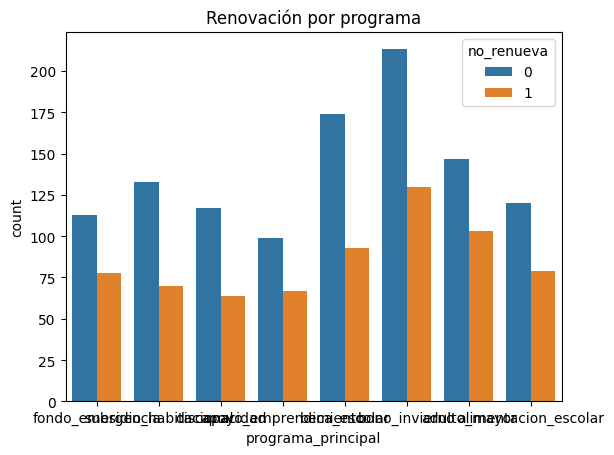

In [ ]:
sns.countplot(x='programa_principal', hue='no_renueva', data=df)
plt.title("Renovación por programa")
plt.show()

In [ ]:
df['grupo_visitas'] = pd.cut(df['num_visitas_asistente'], bins=5)

pd.crosstab(df['grupo_visitas'], df['no_renueva'])

no_renueva,0,1
grupo_visitas,,
"(-0.009, 1.8]",266,208
"(1.8, 3.6]",503,298
"(3.6, 5.4]",198,96
"(5.4, 7.2]",51,12
"(7.2, 9.0]",10,0


ahora ajustaremos valores  y los datos para el modelo de prediccion lo pueda leer con mejor precision.

In [ ]:
df = pd.get_dummies(df, drop_first=True)
 # Aca transformamos los textos a valores numericos automaticamente por que asi trabaja el modelo.
# Por ej en vulnerabilidad Alta-media-baja , este comando asignaria valores 0-1-2 para que lo analice mejor el modelo

In [ ]:
X = df.drop("no_renueva", axis=1)
y = df["no_renueva"]
# Aca ya entramos a configurar las variables de las columnas que usara el modelo, queremos que el modelo sea capaz de predecir cuando alguien no va a renovar (1)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import KNNImputer

pipe_log = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

scores = cross_val_score(
    pipe_log,
    X,
    y,
    cv=5,
    scoring='recall'
)

print("Recall promedio CV clase 1:", scores.mean())

Recall promedio CV clase 1: 0.8011807642765134


Se aplicó validación cruzada con 5 particiones utilizando un pipeline que integra imputación mediante KNN, escalamiento de variables y regresión logística. Se obtuvo un recall promedio de 0.80 en la detección de casos de no renovación, lo que indica una capacidad consistente del modelo para identificar beneficiarios en riesgo.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Hacemos el split de los datos en entrenamiento (80%) y prueba (20%) que son los valores mas comunes

In [ ]:
imputer = KNNImputer(n_neighbors=5)

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)
#“Se utilizó KNNImputer tanto en validación cruzada como en el modelo final, asegurando consistencia en el tratamiento de valores faltantes.
# Utilizamos KNNImputer para rellenar los valores nulos en num_visitas_asistente, no rellenamos arbitrariamente como lo haciamos antes.

In [ ]:
pd.DataFrame(X_train).isnull().sum() # Verificamos que no quedaron valores nulos. (Todos deben decir 0)

,0
num_beneficios_activos,0
recibe_mas_de_uno,0
monto_mensual_clp,0
dias_tramite,0
num_visitas_asistente,0
postulo_digitalmente,0
documentos_completos,0
anios_en_sistema,0
renovaciones_previas,0
tuvo_baja_anterior,0


In [ ]:
print(df.select_dtypes(include='object').columns)
print(df.head())

Index([], dtype='object')
   num_beneficios_activos  recibe_mas_de_uno  monto_mensual_clp  dias_tramite  \
0                       4                  1              33000            17   
1                       2                  1             119000            28   
2                       1                  0              27000            23   
3                       3                  1             172000            31   
4                       4                  1              68000            10   

   num_visitas_asistente  postulo_digitalmente  documentos_completos  \
0                    2.0                     1                     0   
1                    2.0                     0                     1   
2                    3.0                     0                     1   
3                    4.0                     1                     1   
4                    4.0                     0                     0   

   anios_en_sistema  renovaciones_previas  tuvo_baja_a

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Escalamos los datos ya que es importante para el modelo de regresion logistica

In [ ]:
print(X_train[:5])  # Verificamos que se aplico el escalado

[[ 0.02308539  0.95650071 -0.46795074 -1.01152152  0.36361255  1.44802424
   0.54310591 -0.79999688 -1.58921094 -0.52807503 -0.38987177 -0.52807503
  -0.5075844  -0.46940279  2.51931316  1.22651858 -0.1531475  -0.43146431
  -0.38631829 -0.50866616 -0.54846423 -0.4108907  -0.44609509  1.30448785
  -0.34099717 -0.31899805 -0.42692623 -0.49130368 -0.33461786  2.80871659
  -0.35355339  1.09016047 -0.43711211 -0.18368486 -0.06989175]
 [-0.80798878 -1.04547753  0.35453286 -0.31386478 -0.29883946 -0.69059617
  -1.8412615  -0.17382281  0.92904353  1.89367031 -0.38987177 -0.52807503
  -0.5075844  -0.46940279  2.51931316 -0.81531582 -0.1531475  -0.43146431
  -0.38631829 -0.50866616 -0.54846423 -0.4108907  -0.44609509  1.30448785
  -0.34099717 -0.31899805 -0.42692623 -0.49130368 -0.33461786 -0.3560345
   2.82842712  1.09016047 -0.43711211 -0.18368486 -0.06989175]
 [ 0.85415957  0.95650071 -0.73819536  0.9070345   0.36361255 -0.69059617
   0.54310591  2.66043876 -0.95964732 -0.52807503 -0.38987177

MODELOS DE PREDICCION. ocuparemos 3 modelos para hacer una comparacion y ver qe modelo  es mas preciso para el modelo de negocio .

MODELO LOGISTCREGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000) # Creamos el modelo de clasificación (regresión logística)
modelo.fit(X_train, y_train) # Entrenamos el modelo con los datos de entrenamiento

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import classification_report

y_pred = modelo.predict(X_test)
print(classification_report(y_test, y_pred))
# Obtenemos las métricas para saber la 'puntuacion' y fiabilidad de nuestro modelo
# Obteniendo una precision promedio de 84%, lo cual es bastante bueno

              precision    recall  f1-score   support

           0       0.89      0.92      0.90       231
           1       0.84      0.79      0.82       129

    accuracy                           0.87       360
   macro avg       0.87      0.85      0.86       360
weighted avg       0.87      0.87      0.87       360



In [ ]:
coef = pd.DataFrame({
    "Variable": X.columns,
    "Impacto": modelo.coef_[0]
}).sort_values(by="Impacto", ascending=False)

coef.head(10)
# Con esto obtenemos las variables que mas influyen para que 'no renuevan' sea 1, cuales son las que aumentan la posibilidad de ese caso
# Y ya podemos empezar a planear nuestras estrategias, ya que sabemos cuales son los puntos que debemos reforzar

,Variable,Impacto
3,dias_tramite,2.814698
9,tuvo_baja_anterior,1.105046
17,sector_comuna_rural_este,0.730967
18,sector_comuna_rural_oeste,0.604180
22,nivel_vulnerabilidad_extrema,0.521669
10,tramo_etario_18-29,0.238553
11,tramo_etario_30-44,0.167746
23,nivel_vulnerabilidad_media,0.115882
13,tramo_etario_60-74,0.106808
12,tramo_etario_45-59,0.105569


MODELO XGBOOST

In [ ]:
from sklearn.impute import KNNImputer
from xgboost import XGBClassifier

In [ ]:
modelo_xgb = XGBClassifier(eval_metric='logloss', random_state=42)

modelo_xgb.fit(X_train, y_train)

y_pred_xgb = modelo_xgb.predict(X_test)


In [ ]:
print("XGBoost:")
print(classification_report(y_test, y_pred_xgb))

XGBoost:
              precision    recall  f1-score   support

           0       0.84      0.87      0.85       231
           1       0.74      0.70      0.72       129

    accuracy                           0.81       360
   macro avg       0.79      0.78      0.79       360
weighted avg       0.80      0.81      0.80       360



In [ ]:
from sklearn.metrics import classification_report

print("Regresión logística:")
print(classification_report(y_test, y_pred))

print("XGBoost:")
print(classification_report(y_test, y_pred_xgb))

Regresión logística:
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       231
           1       0.84      0.79      0.82       129

    accuracy                           0.87       360
   macro avg       0.87      0.85      0.86       360
weighted avg       0.87      0.87      0.87       360

XGBoost:
              precision    recall  f1-score   support

           0       0.84      0.87      0.85       231
           1       0.74      0.70      0.72       129

    accuracy                           0.81       360
   macro avg       0.79      0.78      0.79       360
weighted avg       0.80      0.81      0.80       360



modelo randomforest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier()
modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

print("Random Forest:")
print(classification_report(y_test, y_pred_rf))

Random Forest:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       231
           1       0.80      0.65      0.72       129

    accuracy                           0.82       360
   macro avg       0.81      0.78      0.79       360
weighted avg       0.82      0.82      0.81       360



COMPARACION DE MODELOS

In [ ]:
print("Random Forest:")
print(classification_report(y_test, y_pred_rf))

print("Regresión logística:")
print(classification_report(y_test, y_pred))

print("XGBoost:")
print(classification_report(y_test, y_pred_xgb))

Random Forest:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       231
           1       0.80      0.65      0.72       129

    accuracy                           0.82       360
   macro avg       0.81      0.78      0.79       360
weighted avg       0.82      0.82      0.81       360

Regresión logística:
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       231
           1       0.84      0.79      0.82       129

    accuracy                           0.87       360
   macro avg       0.87      0.85      0.86       360
weighted avg       0.87      0.87      0.87       360

XGBoost:
              precision    recall  f1-score   support

           0       0.84      0.87      0.85       231
           1       0.74      0.70      0.72       129

    accuracy                           0.81       360
   macro avg       0.79      0.78      0.79       360
weighted avg       0.80      

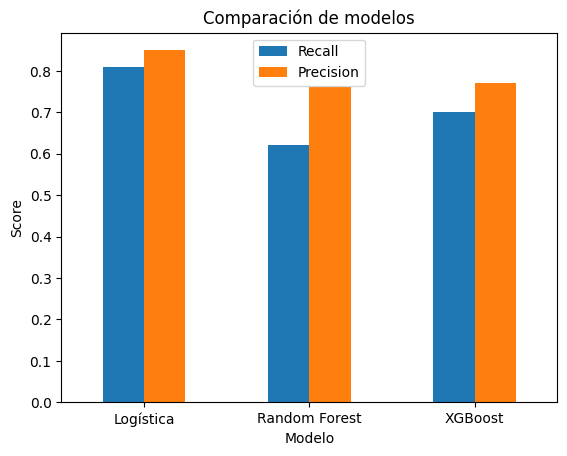

In [ ]:
data = {
    "Modelo": ["Logística", "Random Forest", "XGBoost"],
    "Recall": [0.81, 0.62, 0.70],
    "Precision": [0.85, 0.76, 0.77]
}

df_modelos = pd.DataFrame(data)

df_modelos.set_index("Modelo").plot(kind='bar')
plt.title("Comparación de modelos")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

MODELO CON MAS PRECISION LOGIST

In [ ]:
coef = pd.DataFrame({
    "Variable": X.columns,
    "Impacto": modelo.coef_[0]
}).sort_values(by="Impacto", ascending=False)

coef.head(10)

,Variable,Impacto
3,dias_tramite,2.814698
9,tuvo_baja_anterior,1.105046
17,sector_comuna_rural_este,0.730967
18,sector_comuna_rural_oeste,0.604180
22,nivel_vulnerabilidad_extrema,0.521669
10,tramo_etario_18-29,0.238553
11,tramo_etario_30-44,0.167746
23,nivel_vulnerabilidad_media,0.115882
13,tramo_etario_60-74,0.106808
12,tramo_etario_45-59,0.105569


In [ ]:
coef.tail(10)

,Variable,Impacto
14,tramo_etario_75+,-0.115988
19,sector_comuna_urbano_norte,-0.119148
31,"grupo_visitas_(1.8, 3.6]",-0.304043
6,documentos_completos,-0.315219
4,num_visitas_asistente,-0.334414
34,"grupo_visitas_(7.2, 9.0]",-0.345839
32,"grupo_visitas_(3.6, 5.4]",-0.355357
33,"grupo_visitas_(5.4, 7.2]",-0.360458
7,anios_en_sistema,-1.476729
8,renovaciones_previas,-1.721155


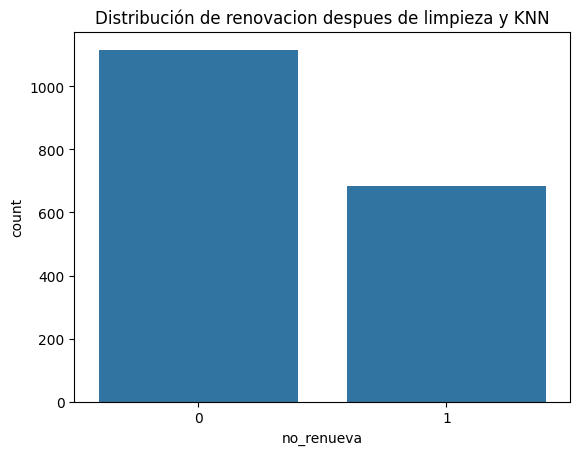

In [ ]:
sns.countplot(x='no_renueva', data=df)
plt.title("Distribución de renovacion despues de limpieza y KNN")
plt.show()